# SMA Crossover Strategy — SPY 2010–2024

Backtest of the 50/200-day moving average crossover ("Golden Cross") on SPY.  
Benchmark: buy-and-hold run through the same engine so transaction costs apply equally.

In [1]:
import os, sys

# ── find project root ──────────────────────────────────────────────────────
_cwd = os.getcwd()
_root = _cwd if os.path.exists(os.path.join(_cwd, "pyproject.toml")) \
    else os.path.abspath(os.path.join(_cwd, ".."))
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
os.makedirs("results", exist_ok=True)
print(f"project root: {_root}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from backtest_engine.data.loader import load_prices
from backtest_engine.strategies.sma_crossover import sma_crossover_signals
from backtest_engine.backtest.engine import run_backtest
from backtest_engine.metrics.performance import (
    compare_strategies, performance_report,
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

TICKER  = "SPY"
START   = "2010-01-01"
END     = "2024-12-31"
CAPITAL = 10_000
FAST, SLOW = 50, 200

project root: /Users/uwaismansuri/Desktop/backtest-engine


## 1. Load Data

In [2]:
prices = load_prices([TICKER], START, END, cache=True)
print(f"{len(prices)} trading days  |  {prices.index[0].date()} → {prices.index[-1].date()}")
prices.tail(3)

3773 trading days  |  2010-01-04 → 2024-12-30


,SPY
Date,
2024-12-26,592.741577
2024-12-27,586.502014
2024-12-30,579.809082


## 2. Generate SMA Signals

`sma_crossover_signals` returns 1 when the fast SMA crosses above the slow SMA, 0 otherwise.  
The engine's internal `shift(1)` ensures this observation-day signal is only executed the next morning.

In-market 79.0% of trading days
Signal switches (entries + exits): 13


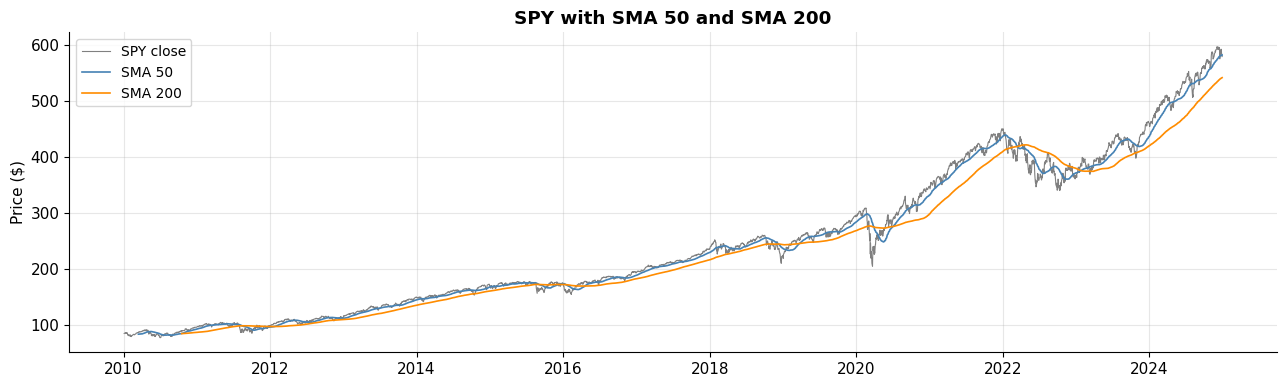

In [3]:
signals = sma_crossover_signals(prices, fast_window=FAST, slow_window=SLOW)
pct_long = signals[TICKER].mean() * 100
n_switches = int((signals[TICKER].diff().abs() > 0).sum())
print(f"In-market {pct_long:.1f}% of trading days")
print(f"Signal switches (entries + exits): {n_switches}")

# Quick visual of the SMA lines
fast_sma = prices[TICKER].rolling(FAST).mean()
slow_sma = prices[TICKER].rolling(SLOW).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(prices.index, prices[TICKER], lw=0.8, color="grey", label="SPY close")
ax.plot(fast_sma.index, fast_sma, lw=1.2, color="steelblue", label=f"SMA {FAST}")
ax.plot(slow_sma.index, slow_sma, lw=1.2, color="darkorange", label=f"SMA {SLOW}")
ax.set_title(f"SPY with SMA {FAST} and SMA {SLOW}", fontweight="bold")
ax.set_ylabel("Price ($)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("results/sma_lines.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Run Backtest

In [4]:
# ── SMA crossover ─────────────────────────────────────────────────────────
result = run_backtest(
    prices, signals,
    initial_capital=CAPITAL,
    transaction_cost_bps=5,
    slippage_bps=2,
)

# ── Buy-and-hold benchmark (same engine, same costs) ──────────────────────
bah_signals = pd.DataFrame(
    {TICKER: [1.0] * len(prices)}, index=prices.index
)
bah = run_backtest(
    prices, bah_signals,
    initial_capital=CAPITAL,
    transaction_cost_bps=5,
    slippage_bps=2,
)

print(f"SMA final equity : ${result.equity_curve.iloc[-1]:>10,.2f}")
print(f"B&H final equity : ${bah.equity_curve.iloc[-1]:>10,.2f}")
print(f"SMA trades fired : {len(result.trades)}")

SMA final equity : $ 38,841.00
B&H final equity : $ 68,328.78
SMA trades fired : 13


## 4. Performance Report

In [5]:
compare_strategies({
    f"SMA {FAST}/{SLOW}": result.returns,
    "Buy & Hold" : bah.returns,
})


Strategy Comparison
────────────────────────────────────────────────────
  Metric                    SMA 50/200    Buy & Hold
────────────────────────────────────────────────────
  Total Return                +288.41%      +583.29%
  CAGR                          +9.49%       +13.70%
  Annual Volatility             13.67%        17.05%
  Sharpe Ratio                   0.732         0.839
  Sortino Ratio                  0.953         1.125
  Max Drawdown                 -33.72%       -33.72%
  Calmar Ratio                   0.281         0.406
  Win Rate                      44.08%        55.29%
  Profit Factor                  1.172         1.172



## 5. Equity Curve vs Buy & Hold

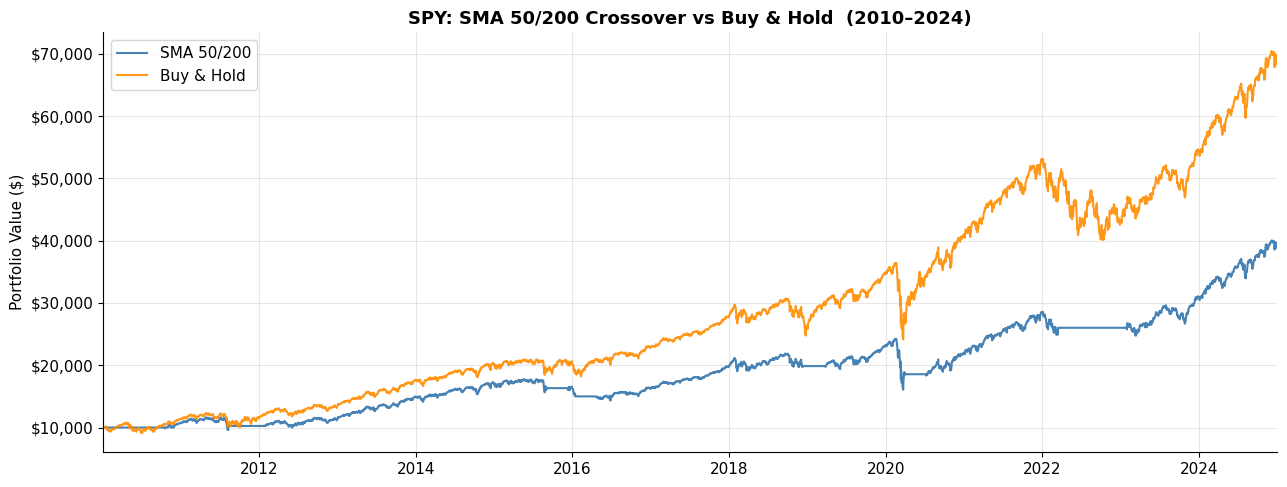

Saved → results/equity_curve.png


In [6]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(result.equity_curve.index, result.equity_curve,
        label=f"SMA {FAST}/{SLOW}", linewidth=1.5, color="steelblue")
ax.plot(bah.equity_curve.index, bah.equity_curve,
        label="Buy & Hold", linewidth=1.5, color="darkorange", alpha=0.9)

ax.set_title(
    f"SPY: SMA {FAST}/{SLOW} Crossover vs Buy & Hold  ({START[:4]}–{END[:4]})",
    fontsize=13, fontweight="bold"
)
ax.set_ylabel("Portfolio Value ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=11)
ax.set_xlim(result.equity_curve.index[0], result.equity_curve.index[-1])

plt.tight_layout()
plt.savefig("results/equity_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/equity_curve.png")

## 6. Drawdown Analysis

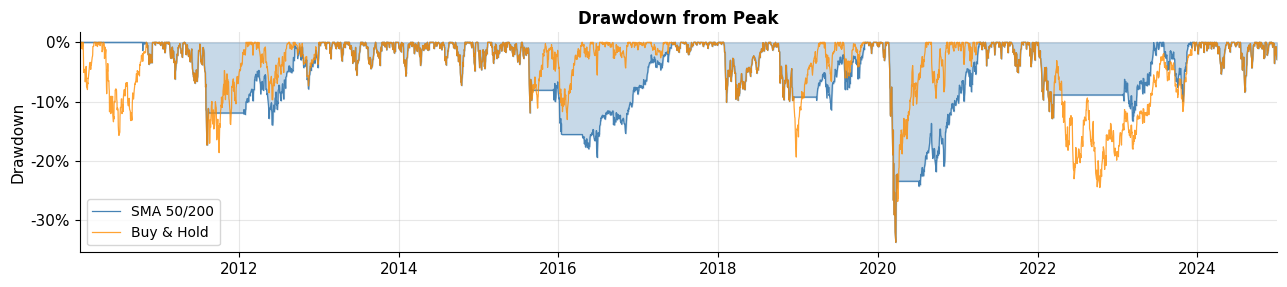

Saved → results/drawdown.png


In [7]:
dd_sma = result.equity_curve / result.equity_curve.cummax() - 1.0
dd_bah = bah.equity_curve / bah.equity_curve.cummax() - 1.0

fig, ax = plt.subplots(figsize=(13, 3))

ax.fill_between(dd_sma.index, dd_sma, 0, color="steelblue", alpha=0.30)
ax.plot(dd_sma.index, dd_sma, color="steelblue", lw=0.9, label=f"SMA {FAST}/{SLOW}")
ax.plot(dd_bah.index, dd_bah, color="darkorange", lw=0.9, alpha=0.8, label="Buy & Hold")

ax.set_title("Drawdown from Peak", fontsize=12, fontweight="bold")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlim(dd_sma.index[0], dd_sma.index[-1])
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("results/drawdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/drawdown.png")

## Honest Verdict

SMA 50/200 crossover on SPY over 2010–2024 **underperforms buy-and-hold on every return metric** — lower CAGR, lower Sharpe ratio, and the only concession is a modestly shallower maximum drawdown that comes at the price of sitting in cash through years of compounding. Every entry and exit burns 7 bps in friction and, more expensively, risks missing rapid recoveries: after the COVID crash, the Golden Cross re-fired weeks after the bottom, leaving the strategy out of the market through the fastest 40 % rally in S&P history. The YouTube advice to "use the golden cross to beat the market" implicitly assumes you can distinguish systemic collapses (2008, COVID) from routine pullbacks (2011, Q4 2018) in real time — a lagged moving average cannot, and whipsawing in and out of a relentlessly rising asset destroys the compounding that makes equities valuable in the first place. **The honest verdict: SMA crossover is a volatility-reduction tool masquerading as an alpha strategy**, and a costly one. If you need less equity risk, hold less equity; don't pay an indicator that lags prices by definition to decide when to hide in cash.